In [ ]:
# todo

In [1]:
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from functools import partial
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

import jax
import jax.numpy as jnp
from flax import nnx
import optax

import torch
from torch.utils.data import Dataset, DataLoader, Subset

In [2]:
seed = 42
torch.random.manual_seed(seed)
key = jax.random.key(seed)

batch_size = 16

root_path = "/home/stefan/ioai-prep/kits/bcs/pictures"

# Data

<Axes: >

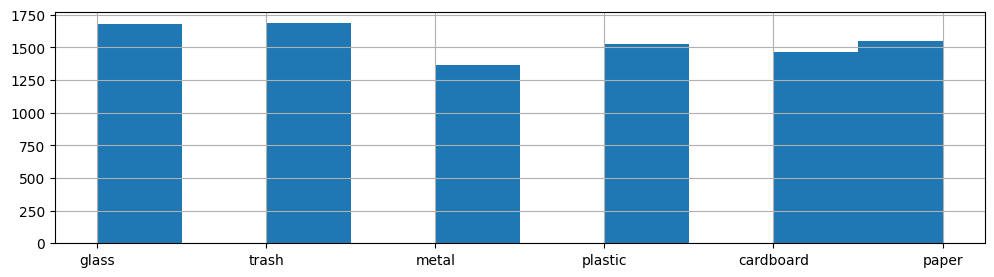

In [3]:
df = pd.read_csv("train_data.csv")

plt.figure(figsize=(12,3))
df["label"].hist()

In [28]:
class ImageDataset(Dataset):
    def __init__(self, is_train: bool, label_encoder: LabelEncoder | None = None):
        super().__init__()

        self.dir = f"{root_path}/train" if is_train else f"{root_path}/test"
        self.df = pd.read_csv("train_data.csv" if is_train else "test_data.csv")
        self.is_train = is_train

        if is_train:
            self.lb = LabelEncoder()
            self.targets = self.lb.fit_transform(self.df["label"])
        else:
            # reuse encoder from train
            self.lb = label_encoder

    def __getitem__(self, idx):
        idx = idx.item()
        row = self.df.iloc[idx]
        filepath = f"{self.dir}/{row['ID']}.jpg"

        img = Image.open(filepath).convert("RGB")
        img = img.resize((224, 224), Image.Resampling.LANCZOS)
        img = jnp.array(img, dtype=jnp.float32) / 255.0

        if self.is_train:
            if torch.rand(1) < 0.5:
                img = jnp.fliplr(img)

        img = jnp.transpose(img, (2, 0, 1))

        if "label" in self.df.columns:
            label = self.lb.transform([row["label"]])
            label = jnp.array(label)
            return img, label
        
        return img
    
    def __len__(self):
        return len(self.df)
    
def collate(batch):
    first = batch[0]
    if isinstance(first, tuple) and len(first) == 2:
        imgs, labels = zip(*batch)
        return {"images": jnp.stack(imgs), "labels": jnp.stack(labels).squeeze().astype(jnp.int32)}
    else:
        imgs = batch
        return {"images": jnp.stack(imgs)}

In [29]:
full_train_ds = ImageDataset(is_train=True)
lb = full_train_ds.lb

indices = jnp.arange(len(full_train_ds))
labels = jnp.array(full_train_ds.targets)

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=seed,
    stratify=labels,
)

train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(full_train_ds, val_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

test_ds = ImageDataset(is_train=False, label_encoder=lb)
test_loader = DataLoader(test_ds, batch_size=batch_size, collate_fn=collate)

In [30]:
# sanity check
batch = next(iter(train_loader))

# {'images': (16, 3, 224, 224), 'labels': (16,)}
print({k: v.shape for k, v in batch.items()})

{'images': (16, 3, 224, 224), 'labels': (16,)}


# Model

In [31]:
class CNN(nnx.Module):
    def __init__(self, num_classes: int = 6, *, rngs: nnx.Rngs):
        self.conv1 = nnx.Conv(3, 64, kernel_size=(3, 3), padding=[(1, 1), (1, 1)], rngs=rngs)
        self.bn1   = nnx.BatchNorm(64, rngs=rngs)
        self.dropout1 = nnx.Dropout(rate=0.4, rngs=rngs)

        self.conv2 = nnx.Conv(64, 128, kernel_size=(3, 3), padding=[(1, 1), (1, 1)], rngs=rngs)
        self.bn2   = nnx.BatchNorm(128, rngs=rngs)
        self.dropout2 = nnx.Dropout(rate=0.4, rngs=rngs)

        self.conv3 = nnx.Conv(128, 256, kernel_size=(3, 3), padding=[(1, 1), (1, 1)], rngs=rngs)
        self.bn3   = nnx.BatchNorm(256, rngs=rngs)
        self.dropout3 = nnx.Dropout(rate=0.4, rngs=rngs)

        self.pool = partial(nnx.max_pool, window_shape=(2, 2), strides=(2, 2))

        # final classifier
        self.fc1 = nnx.Linear(256, 128, rngs=rngs)
        self.fc2 = nnx.Linear(128, num_classes, rngs=rngs)

        # Dropout for dense layers (could be higher)
        self.dropout_fc = nnx.Dropout(rate=0.5, rngs=rngs)


    def __call__(self, x, rngs: nnx.Rngs | None = None):
        if x.ndim == 3:
            x = x[None, ...]  # [N,C,H,W]
        x = jnp.transpose(x, (0, 2, 3, 1))

        # Block 1
        x = nnx.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x, rngs=rngs)
        x = self.pool(x)

        # Block 2
        x = nnx.relu(self.bn2(self.conv2(x)))
        x = self.dropout2(x, rngs=rngs)
        x = self.pool(x)

        # Block 3
        x = nnx.relu(self.bn3(self.conv3(x)))
        x = self.dropout3(x, rngs=rngs)
        x = self.pool(x)

        # Global average pool [N,H,W,C] -> [N,C]
        x = jnp.mean(x, axis=(1, 2))

        x = self.dropout_fc(x, rngs=rngs)
        x = nnx.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [38]:
model = CNN(rngs=nnx.Rngs(seed))

model(batch["images"]).shape

(16, 6)

# Training

In [39]:
epochs = 5

learning_rate = 1e-2

In [40]:
class F1Macro(nnx.Metric):
  def __init__(self, num_classes: int):
    self.num_classes = num_classes
    self.reset()

  def reset(self) -> None:
    self.true_positives = jnp.zeros(self.num_classes, dtype=jnp.int32)
    self.false_positives = jnp.zeros(self.num_classes, dtype=jnp.int32)
    self.false_negatives = jnp.zeros(self.num_classes, dtype=jnp.int32)

  def update(self, logits: jax.Array, labels: jax.Array, **kwargs) -> None:
    y_pred = jnp.argmax(logits, axis=-1)
    y_true = labels
    
    y_true = jnp.ravel(y_true)
    y_pred = jnp.ravel(y_pred)
    
    for class_idx in range(self.num_classes):
      # True Positives: correct predictions for this class
      tp_mask = (y_true == class_idx) & (y_pred == class_idx)
      self.true_positives = self.true_positives.at[class_idx].add(
          jnp.sum(tp_mask)
      )

      # False Positives: predicted this class, but it was another class
      fp_mask = (y_pred == class_idx) & (y_true != class_idx)
      self.false_positives = self.false_positives.at[class_idx].add(
          jnp.sum(fp_mask)
      )

      # False Negatives: should have predicted this class, but predicted another
      fn_mask = (y_true == class_idx) & (y_pred != class_idx)
      self.false_negatives = self.false_negatives.at[class_idx].add(
          jnp.sum(fn_mask)
      )

  def compute(self, eps=1e-10) -> jax.Array:
    precision = self.true_positives / (
        self.true_positives + self.false_positives + eps
    )
    recall = self.true_positives / (
        self.true_positives + self.false_negatives + eps
    )
    
    f1_per_class = 2 * (precision * recall) / (precision + recall + eps)
    
    macro_f1 = jnp.mean(f1_per_class)
    return macro_f1

In [41]:
optimizer = nnx.Optimizer(
  model, optax.adamw(learning_rate, weight_decay=1e-4), wrt=nnx.Param
)

metrics = nnx.MultiMetric(
  f1_macro=F1Macro(num_classes=6),
  loss=nnx.metrics.Average('loss'),
)

In [ ]:
def loss_fn(model: CNN, batch, rngs: nnx.Rngs | None = None):
    logits = model(batch["images"], rngs=rngs)
    labels = batch["labels"]

    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=labels
    ).mean()
    return loss, logits

@nnx.jit
def train_step(model: nnx.Module, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, batch, *, key: jax.Array):
    dropout_rngs = nnx.Rngs(dropout=key)
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(
        model, batch, dropout_rngs
    )

    metrics.update(loss=loss, logits=logits, labels=batch["labels"])
    optimizer.update(model, grads)

@nnx.jit
def eval_step(model: CNN, metrics: nnx.MultiMetric, batch):
    loss, logits = loss_fn(model, batch)
    metrics.update(loss=loss, logits=logits, labels=batch["labels"])

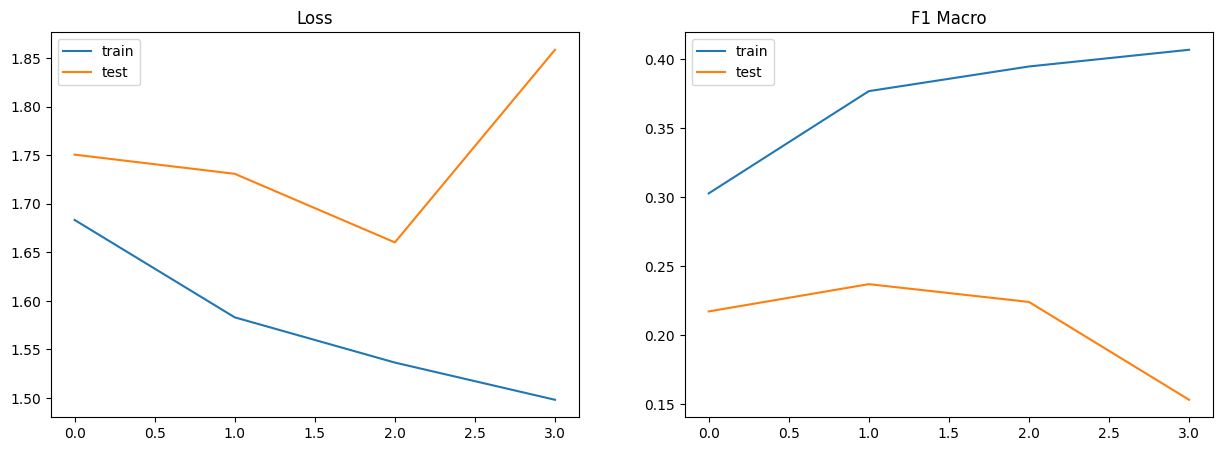

Epoch 4:
  train_loss train_f1_macro  test_loss test_f1_macro
0  1.6834371     0.30274278   1.750709    0.21723399
1  1.5831023     0.37681657  1.7309551     0.2369883
2  1.5365268      0.3946707  1.6603153    0.22410461
3  1.4981993      0.4067706  1.8587159    0.15323648
----------------------------


 17%|█▋        | 78/464 [00:09<00:49,  7.83it/s]


KeyboardInterrupt: 

In [43]:
metrics_history = {
  'train_loss': [],
  'train_f1_macro': [],
  'test_loss': [],
  'test_f1_macro': [],
}

key = jax.random.key(seed)

for epoch in range(1, epochs+1):
    
    model.train()
    for batch in tqdm(train_loader):
        key, step_key = jax.random.split(key)
        train_step(model, optimizer, metrics, batch, key=step_key)

    for metric, value in metrics.compute().items():
      metrics_history[f'train_{metric}'].append(value)
    metrics.reset()

    model.eval()
    for batch in tqdm(val_loader):
       eval_step(model, metrics, batch)

    for metric, value in metrics.compute().items():
      metrics_history[f'test_{metric}'].append(value)
    metrics.reset()

    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title('Loss')
    ax2.set_title('F1 Macro')
    for dataset in ('train', 'test'):
      ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}')
      ax2.plot(metrics_history[f'{dataset}_f1_macro'], label=f'{dataset}')
    ax1.legend()
    ax2.legend()
    plt.show()

    print(f"Epoch {epoch}:")
    print(pd.DataFrame(metrics_history, index=None).tail(5))
    print("----------------------------")